<a href="https://colab.research.google.com/github/claramanolache/ML_Intro/blob/main/Week_2_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Instructions

For this assignment, you will use the dataset loaded below (or another appropriate dataset of your choice) and perform the following steps that were demonstrated in the practice Notebook.

**Do not delete any instructor-provided cells from this Notebook.** If you accidentally delete a cell, you can either undo the action or load a copy of the original assignment Notebook in a new browser tab and copy over the missing cells.

**You can and should add cells to this Notebook.** To add a markdown (text) cell, hover your cursor beneath the cell where you want to insert and click the "+Text" button. To add a Python (code) cell, click the "+Code" button.

Steps:
- Inspect the data
  - Display each column's data types
  - For any non-numerical columns, display all possible values
  - Create histograms of all the columns
  - In a markdown (text) cell, briefly write about your findings. Do you see anything that might cause problems for your model?
- Visualize the data
  - Create one or more plots of the data
    - Tip: Experiment with different types of plots
  - In a markdown (text) cell, briefly describe your findings. Did you find anything unexpected in the data?
- Prepare the data
  - Remove null values
    - Explain your reasoning for the approach you chose.
  - Encode categorical features
  - Scale the original numerical features
  - Combine all columns using a method of your choice
    - Recommended: Use `make_column_transformer`
- Train a Model
  - Instantiate a Linear Regression model
  - Fit the training data to the model
- Evaluate the Model
  - Predict labels **using the training data**
    - Use RMSE to see how well your model did on the training labels
  - Predict labels **using the testing data**
    - Use RMSE to see how well your model did on the testing labels
  - In a markdown (text) cell, briefly describe your findings. Based on how the model performed on the training and testing data, does it appear to have overfit or underfit the data?
- Submit your Notebook as a PDF.
  - Re-run all cells using "Run all" at the top.
  - From the File menu, select Print to download as a PDF.
  - Upload this PDF to Canvas.

# Import Libraries

In [1]:
import numpy as np
import pandas as pd

from sklearn import compose
from sklearn import linear_model
from sklearn import metrics
from sklearn import model_selection
from sklearn import pipeline
from sklearn import preprocessing
from sklearn import tree

# Load the Dataset

This dataset contains records of individual medical insurance costs from people across the United States. Each record tracks both the actual amount billed by health insurance (the `charges` column) and personal information about the insured such as age, gender, body mass index (BMI), whether they smoke, how many children they have, and which region of the US they live in.

These factors are known to influence medical expenses and insurance premiums. The goal of analyzing this dataset is to understand how demographic and lifestyle details impact medical costs, and to develop models (such as linear regression) that can predict insurance charges for new individuals. This type of analysis is important for insurers, healthcare organizations, and individuals to estimate costs and plan for care.

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/dkauffman-foothill/course-datasets/refs/heads/main/ml/insurance.csv")

# Inspect the Data

Display each column's data types.

In [3]:
print(df.dtypes)

Unnamed: 0      int64
age             int64
sex            object
bmi           float64
children      float64
smoker         object
region         object
charges       float64
dtype: object


For any non-numerical columns, display all possible values.

In [4]:
for column in df.columns:
    if df[column].dtype == 'object':
        print(f"Unique values for column '{column}': {df[column].unique()}")

Unique values for column 'sex': ['female' 'male']
Unique values for column 'smoker': ['yes' 'no' nan]
Unique values for column 'region': ['southwest' 'southeast' 'northwest' 'northeast']


Create histograms of all the columns.

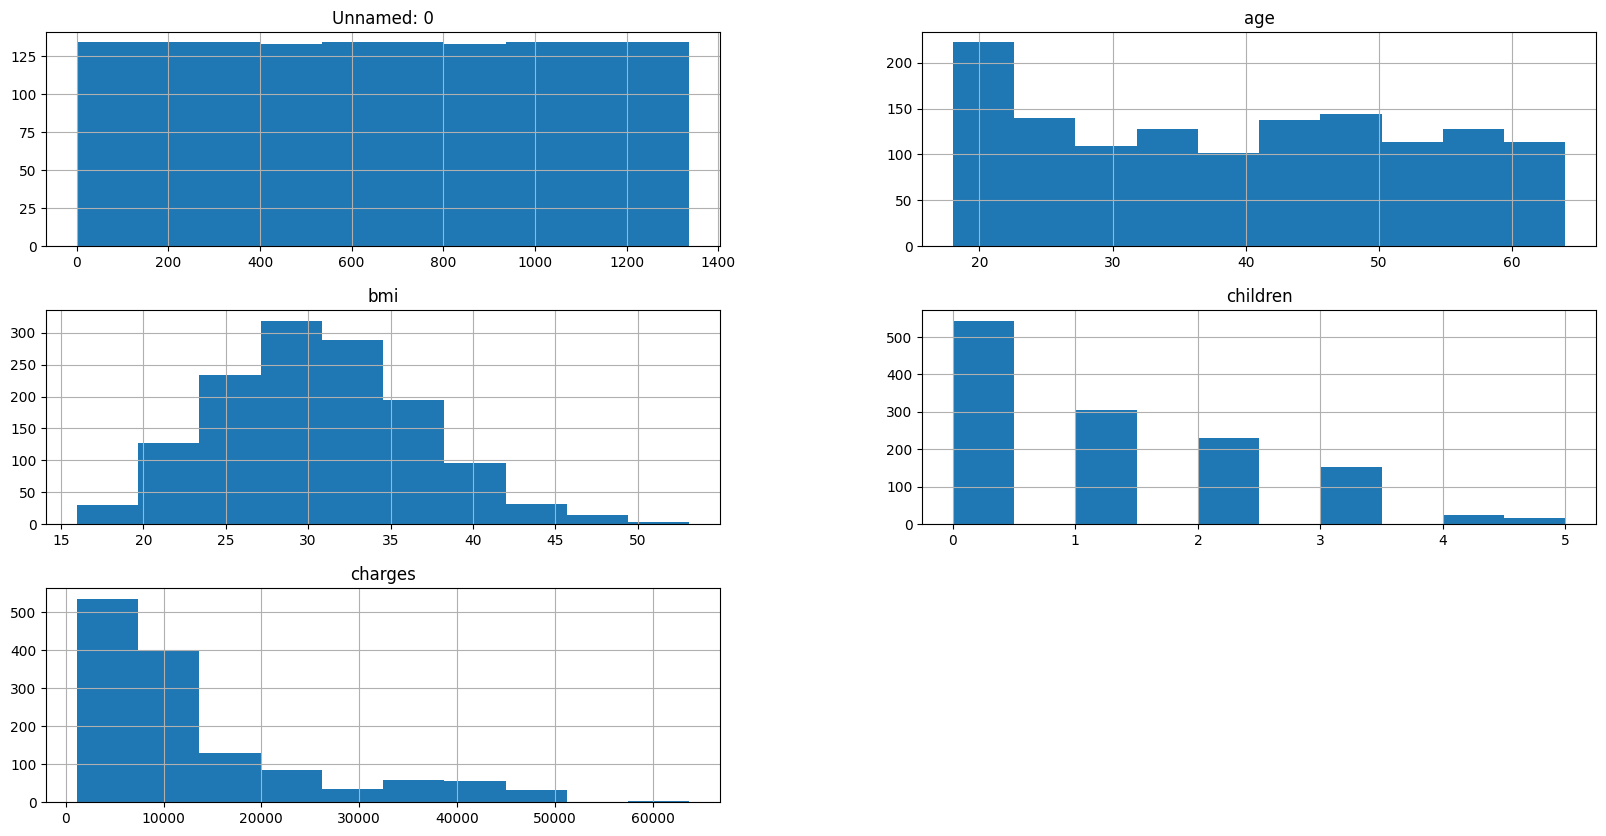

In [5]:
df.hist(figsize=(20, 10));

### Report Findings

Do you see anything that might cause problems for your model?


*   **Unnamed: 0 column**: Because its uniform but all the other colum historgrams dont appear to be uniform, this column might not have very good predictive power. Probably a very simple index that doesn't affect too much. Maybe should be dropped before training model.

*   **BMI column**: Almost normal bell curve, with a little bit of a right skew because of outliers around 50. All other colums (excluding Unnamed) are heavily right skewed so this might be an outlier from the data.

*   **Charges column**: Almost normal bell curve, with a little bit of a right skew because of outliers around 50.



## Visualize the Data

Create one or more plots of the data; experiment with different types of plots.

<Axes: title={'center': 'bmi'}, xlabel='children'>

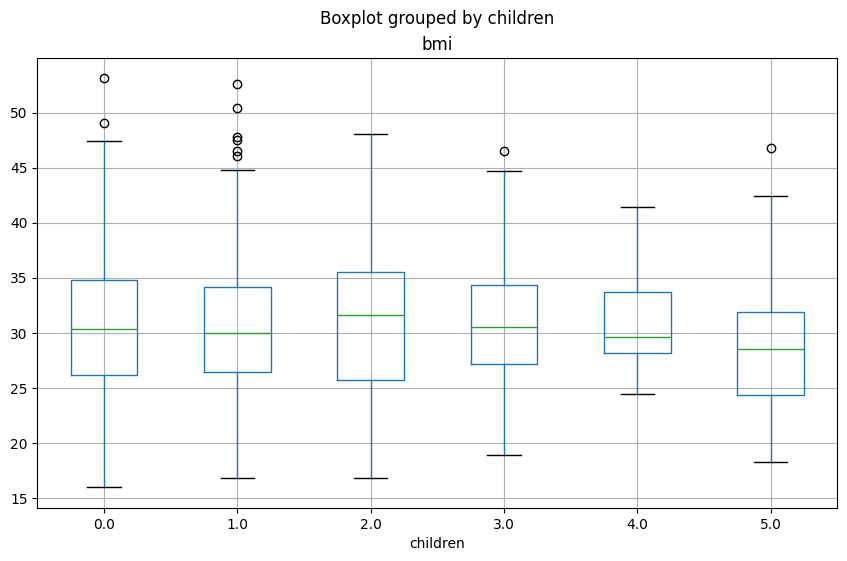

In [6]:
df.boxplot(column='bmi', by='children', figsize=(10, 6))

<Axes: xlabel='bmi', ylabel='charges'>

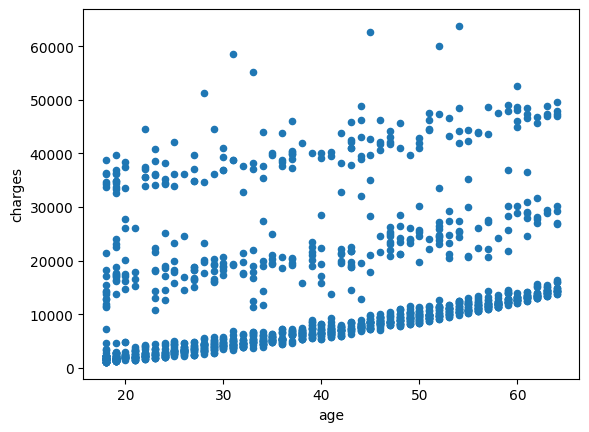

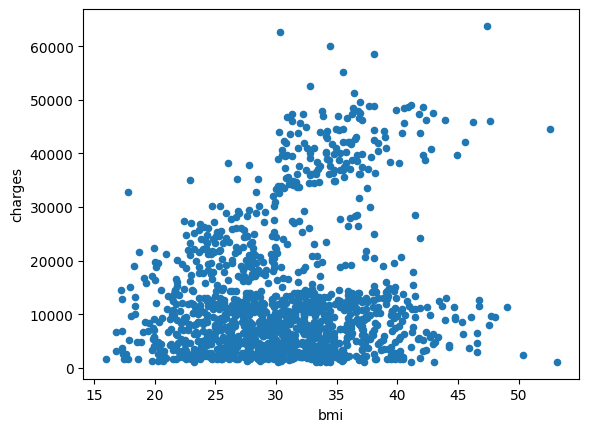

In [7]:
df.plot.scatter(x='age', y='charges')
df.plot.scatter(x='bmi', y='charges')


### Report Findings

Did you find anything unexpected in the data?


There was nothing really intresting in the children vs bmi boxplot. I expected to find an intresting relationship there.


There is strong, linear, positive correlations between age and charges. I expected this to be a postive correlation but I thought it would non-linear and slightly exponential as age increases.

There was little, positive correlation between bmi and charge. I expected this to be a bigger indicator for charges because of higher health complications.

# Prepare the Data

Remove any null values from the data. You can use the approach from the practice exercise, or you can use a different approach. Either way, justify your choice. You can create additional cells to show values such as the ratio of nulls cells.

In [8]:
print('Null values per Column Ratio (%):')
print((df.isnull().sum() / len(df)) * 100)

isnull = df.isnull().any(axis=1)
isnull_index = isnull[isnull].index

df_cleaned = df.drop(isnull_index)

print('\nShape of DataFrame before dropping nulls:', df.shape)
print('Shape of DataFrame after dropping nulls:', df_cleaned.shape)

Null values per Column Ratio (%):
Unnamed: 0    0.000000
age           0.000000
sex           0.000000
bmi           0.000000
children      4.932735
smoker        0.971599
region        0.000000
charges       0.000000
dtype: float64

Shape of DataFrame before dropping nulls: (1338, 8)
Shape of DataFrame after dropping nulls: (1260, 8)


### Justification for Handling Null Values

I used the method in the examples, but modified it because I havent seperated the data into X and Y yet. By making a copy, I can see if this was a success by comparing cleaned vs original shape. Because the size shrunk, that means the cleanse was a success. It also wasn't a substational decrease in any of the features, so it won't impact the accuracy of the results and it was the right decision to clean the data rather than just remove the feature from training.

I also calculated the ratio (in percentage) using sum() and length() functions.


## Convert Categorical Features
You may use one-hot encoding (as in the practice exercise) or a different type of encoding.

In [9]:
df_processed = df_cleaned.drop(columns=['Unnamed: 0'])
cat_features = df_processed[['sex', 'smoker', 'region']]


encoder = preprocessing.OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)
encoded_features = encoder.fit_transform(cat_features)

pd.DataFrame(
    encoded_features,
    columns=encoder.get_feature_names_out(['sex', 'smoker', 'region']),
    index=df_processed.index
).head()

,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
2,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
4,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0


## Scale Numerical Features
You may use standardization (as in the practice exercise) or a different type of numerical scaling.

In [10]:
numerical_only = df.drop(columns=['sex', 'smoker', 'region'], axis=1)
preprocessing.StandardScaler().fit_transform(numerical_only)

array([[-1.73075678, -1.43876426, -0.45332   , -0.91183289,  0.2985838 ],
       [-1.72816777, -1.50996545,  0.5096211 , -0.08395892, -0.95368917],
       [-1.72557875, -0.79795355,  0.38330685,  1.57178902, -0.72867467],
       ...,
       [ 1.72557875, -1.50996545,  1.0148781 , -0.91183289, -0.96159623],
       [ 1.72816777, -1.29636188, -0.79781341, -0.91183289, -0.93036151],
       [ 1.73075678,  1.55168573, -0.26138796, -0.91183289,  1.31105347]])

## Combine Features
Recommended: Use `make_column_transformer` from the practice exercise.

In [12]:
X=df_processed.drop(columns=['charges'])
y=df_processed['charges']
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
transformer = compose.make_column_transformer(
    (
        # Standardize numerical features.
        preprocessing.StandardScaler(),
        compose.make_column_selector(dtype_include=np.number)
    ),
    (
        # Encode non-numerical features.
        preprocessing.OneHotEncoder(),
        compose.make_column_selector(dtype_include=object)
    )
)

X_train = transformer.fit_transform(X_train)
X_test = transformer.transform(X_test)

# Train and Evaluate a Model

Instantiate a Linear Regression model.

In [16]:
lin_reg = linear_model.LinearRegression()

Fit the training data to the model.


In [17]:
lin_reg.fit(X_train, y_train)

LinearRegression()

# Evaluate the Model

Predict labels using the training data. Use RMSE to see how well your model did on the training labels.


In [19]:
y_pred = lin_reg.predict(X_train)

lin_rmse = metrics.root_mean_squared_error(y_train, y_pred)
lin_rmse

6057.963234528537

Predict labels using the testing data. Use RMSE to see how well your model did on the testing labels.


In [20]:
y_pred = lin_reg.predict(X_test)

final_rmse = metrics.root_mean_squared_error(y_test, y_pred)
final_rmse

5621.684248000233

In [23]:
print(df['charges'].mean())

13270.422265141257


Because the LR model did slightly better on unseen data, then we can assume it hasn't been overfitted. However, because the average charge is roughly 13k and the LR model has an RMSE of 5k, this tells us that this model is not a good predictor. So, we can assume it has been underfitted.